# H&E image preparation and feature extraction

This is the first notebook in the ST-to-histology workflow. The histology-side
dataset input is **one high-resolution image**. Spatial coordinates, a Visium
matrix, spot locations, and gene expression from the reference section are not
used to estimate the alignment.

By default this notebook performs feature extraction itself. spAlignDE prepares
the image, runs the hierarchical HIPT encoders with shifted tilings, smooths
the image-feature fields, and saves the result consumed by the clustering
notebook. Documentation maintainers may set
`SPALIGNDE_DOCUMENTATION_FEATURE_DIR` to re-render the page from a previously
completed and validated feature-extraction result; public users do not need
that variable.

## Pipeline implemented here

1. **Standardize the image.** Convert to RGB, read OME physical pixel size when
   available, rescale to 0.5 μm per pixel, and add white padding on the right
   and bottom to a multiple of 224 pixels. A JPEG already at the requested
   scale and compatible size is copied byte-for-byte to avoid re-encoding.
2. **Encode local morphology.** Split each 4,096-pixel context tile into
   256 × 256-pixel patches. ViT-256 produces 384-dimensional tokens on a
   16 × 16-pixel image grid.
3. **Encode larger tissue context.** Stitch the ViT-256 patch representations
   and pass them through ViT-4K, producing 192 context channels on the same
   feature grid.
4. **Reduce tile-boundary artifacts.** Repeat extraction at offsets
   0, 64, 128, and 192 pixels along both axes (16 shifted views) and average
   the overlapping fields. Apply 16 × 16 and 4 × 4 uniform smoothing windows
   to the context and subpatch channels, respectively.
5. **Add image color and save.** Mean-downsample RGB by 16 and write one
   dictionary containing `cls`, `sub`, and `rgb` feature groups.

Thus, one output coordinate corresponds to a 16 × 16-pixel region of the
prepared image. All later histology clustering is performed on this image-only
feature field.

## Data, source code, and pretrained models

The following resources are sufficient to reproduce this feature-extraction
stage. The Xenium query is listed for completeness but is **not read in this
notebook**.

| Resource | Source | What to obtain |
|---|---|---|
| Reference H&E image | [10x Visium CytAssist Post-Xenium Mouse Brain](https://www.10xgenomics.com/datasets/visium-cytassist-gene-expression-libraries-of-post-xenium-mouse-brain-ff-using-the-mouse-whole-transcriptome-probe-set-2-standard) | Control Replicate 1 full-resolution tissue image; the vendor file used here is `CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_image.btf`. |
| Query ST data, used in notebook 3 | [10x Fresh Frozen Mouse Brain Xenium Replicates](https://www.10xgenomics.com/datasets/fresh-frozen-mouse-brain-replicates-1-standard) | Replicate 1 Xenium output bundle. It is not an input to image feature extraction. |
| spAlignDE feature extractor | This installed package | `spAlignDE.extract_histology_features()` implements dense stitching, shifted-view averaging, smoothing, and output serialization. No separate extractor package is required. |
| HIPT model and method | [MahmoodLab/HIPT](https://github.com/mahmoodlab/HIPT) | Official hierarchical ViT implementation and model description. |
| HIPT ViT-256 weights | [official `vit256_small_dino.pth`](https://github.com/mahmoodlab/HIPT/blob/master/HIPT_4K/Checkpoints/vit256_small_dino.pth) | DINO-pretrained ViT-S/16 checkpoint, approximately 672 MB. |
| HIPT ViT-4K weights | [official `vit4k_xs_dino.pth`](https://github.com/mahmoodlab/HIPT/blob/master/HIPT_4K/Checkpoints/vit4k_xs_dino.pth) | DINO-pretrained ViT-XS/256 checkpoint, approximately 378 MB. |
| Optional UNI model | [MahmoodLab/UNI code](https://github.com/mahmoodlab/UNI) and [gated Hugging Face weights](https://huggingface.co/MahmoodLab/UNI) | Optional ViT-L/16 feature model. UNI access requires accepting its terms with an eligible individual account. It is not required for the paper H&E alignment. |

HIPT and UNI have their own licenses and model-use terms. Review those terms
before downloading or redistributing code, checkpoints, or derived models.

### Install spAlignDE and prepare HIPT

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[histology,tutorial]"

mkdir -p external
GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/mahmoodlab/HIPT.git external/HIPT
cd external/HIPT
git lfs pull --include "*.pth"
cd /path/to/spAlignDE

export SPALIGNDE_HIPT_DIR=/path/to/spAlignDE/external/HIPT
```

Git LFS retrieves the two pretrained checkpoints released in the official HIPT
repository. Before running the notebook, verify this layout:

```text
/path/to/spAlignDE/
├── data/cross_modality/histology/mouse_brain/
│   └── CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_image.btf
└── external/HIPT/
    └── HIPT_4K/
        ├── hipt_4k.py
        ├── hipt_model_utils.py
        ├── vision_transformer.py
        ├── vision_transformer4k.py
        └── Checkpoints/
            ├── vit256_small_dino.pth
            └── vit4k_xs_dino.pth
```

The HIPT environment requires compatible PyTorch and torchvision builds. By
default the extractor uses the notebook's Python executable. If HIPT is
installed in a separate compatible environment, set:

```bash
export SPALIGNDE_HIPT_PYTHON=/path/to/hipt-environment/bin/python
```

A CUDA-capable GPU is strongly recommended because shifted extraction runs 16
HIPT views and the BTF-derived feature file is approximately 2.38 GB.

### Place the input image

Place the vendor image at
`data/cross_modality/histology/mouse_brain/CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_image.btf`,
or point to any supported high-resolution image:

```bash
export SPALIGNDE_HISTOLOGY_IMAGE=/path/to/high_resolution_image.btf
```

Accepted inputs are RGB or RGB-convertible JPEG, PNG, TIFF, OME-TIFF, and BTF
images readable by Pillow/tifffile. OME physical pixel size is used when
available. Different source crops or white canvas sizes produce different
feature-grid dimensions. The fixed-seed release run reads the vendor BTF's
0.27381 μm-per-pixel metadata, rescales it to 0.5 μm per pixel, and pads to a
12,768 × 20,608 analysis image, giving a 1,288 × 798 grid.

Coordinates in all downstream image outputs are `(x, y)` feature-grid
coordinates with origin at the upper left. One feature-grid unit represents a
16 × 16-pixel region of the prepared image.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

import spAlignDE

WORKFLOW_SEED = 0
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_DATA_DIR",
        PROJECT_ROOT / "data" / "cross_modality" / "histology" / "mouse_brain",
    )
).expanduser()
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "histology" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
IMAGE_PATH = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_IMAGE",
        DATA_DIR / "CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_image.btf",
    )
).expanduser()
FEATURE_DIR = OUTPUT_DIR / "feature_extraction"

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(
        f"Histology image not found: {IMAGE_PATH}\n"
        "Download the public Replicate 1 image or set SPALIGNDE_HISTOLOGY_IMAGE."
    )

print("Histology input file:", IMAGE_PATH.name)
print("Only the image is used on the reference side.")

Histology input file: CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_image.btf
Only the image is used on the reference side.


## Run image preparation and HIPT feature extraction

The public function below executes all five stages described above. It creates
the feature file from `IMAGE_PATH` on every fresh run; there is no input option
for a precomputed feature file in this notebook.

In [3]:
completed_feature_dir = os.environ.get("SPALIGNDE_DOCUMENTATION_FEATURE_DIR")
if completed_feature_dir:
    import json

    completed_feature_dir = Path(completed_feature_dir).expanduser()
    features = spAlignDE.load_histology_features(
        completed_feature_dir / "he.jpg",
        completed_feature_dir / "embeddings-hist-vit.pickle",
    )
    manifest_path = completed_feature_dir / "histology_feature_manifest.json"
    features.manifest.update(json.loads(manifest_path.read_text()))
    execution_mode = "validated feature-stage output"
else:
    feature_config = spAlignDE.HistologyFeatureConfig(
        target_microns_per_pixel=0.5,
        shifted_tiles=True,
        device=None,  # automatically select CUDA when available
    )
    features = spAlignDE.extract_histology_features(
        IMAGE_PATH,
        FEATURE_DIR,
        config=feature_config,
    )
    execution_mode = "fresh package extraction"

display(
    pd.Series(
        {
            "mode": execution_mode,
            "input image": features.source_image_path.name,
            "prepared image": features.prepared_image_path.name,
            "prepared image size (width, height)": features.image_size_wh,
            "feature grid (height, width)": features.feature_grid_shape_hw,
            "feature file": features.feature_path.name,
            "feature size (GB)": round(features.feature_path.stat().st_size / 1e9, 3),
        },
        name="value",
    ).to_frame()
)

Image loaded: he.jpg
shift 0/256, 0/256


/path/to/assets/HIPT/HIPT_4K/hipt_model_utils.py:61: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  state_dict = torch.load(pretrained_weights, map_location="cpu")


/path/to/assets/HIPT/HIPT_4K/hipt_model_utils.py:97: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  state_dict = torch.load(pretrained_weights, map_location="cpu")


Take key teacher in provided checkpoint dict
Pretrained weights found at /path/to/assets/HIPT/HIPT_4K/Checkpoints/vit256_small_dino.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
# of Patches: 196
Take key teacher in provided checkpoint dict
Pretrained weights found at /path/to/assets/HIPT/HIPT_4K/Checkpoints/vit4k_xs_dino.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
tile 0 / 20


tile 10 / 20


...

single view: 10 sec


Smoothing context channels...


Smoothing subpatch channels...


Saved HIPT feature groups: cls=192, sub=384, rgb=(3, 1288, 798)


,value
mode,fresh package extraction
input image,CytAssist_FreshFrozen_Mouse_Brain_Rep1_tissue_...
prepared image,he.jpg
"prepared image size (width, height)","(12768, 20608)"
"feature grid (height, width)","(1288, 798)"
feature file,embeddings-hist-vit.pickle
feature size (GB),2.38


## Inspect image preparation

The preparation information describes how the downloaded image was converted
to `he.jpg`. If the source provides physical pixel size, `resize_scale` records
the conversion to 0.5 μm per pixel; otherwise spAlignDE preserves the native
resolution and reports the output physical scale as unavailable.

,value
preparation_mode,rescale_pad_and_jpeg_encode
original_size_wh,"[23070, 37252]"
resized_size_wh,"[12634, 20400]"
padded_size_wh,"[12768, 20608]"
source_microns_per_pixel,0.273811
output_microns_per_pixel,0.5
resize_scale,0.547621
pad_right_px,134
pad_bottom_px,208


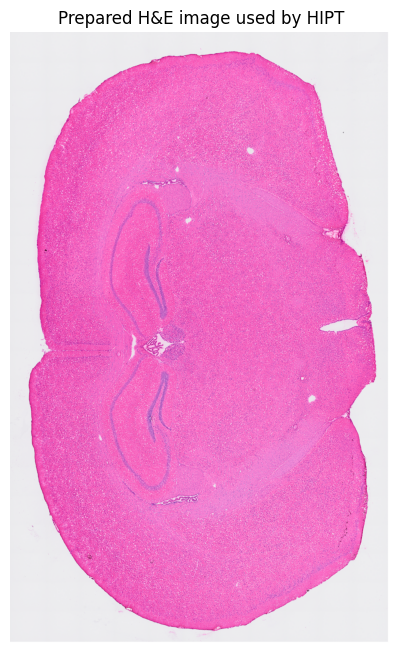

In [4]:
preparation_fields = [
    "preparation_mode",
    "original_size_wh",
    "resized_size_wh",
    "padded_size_wh",
    "source_microns_per_pixel",
    "output_microns_per_pixel",
    "resize_scale",
    "pad_right_px",
    "pad_bottom_px",
]
display(
    pd.Series(
        {field: features.manifest[field] for field in preparation_fields},
        name="value",
    ).to_frame()
)

with Image.open(features.prepared_image_path) as image:
    image.draft("RGB", (1400, 1400))
    prepared_preview = image.convert("RGB")
    prepared_preview.thumbnail((1400, 1400))

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(prepared_preview)
ax.set_title("Prepared H&E image used by HIPT")
ax.axis("off")
plt.show()

## Inspect the extracted feature field

The table below is generated from the saved extraction information rather than
from an expected hard-coded display. For the vendor BTF release input, each channel
has shape 1,288 × 798. `cls` is the 192-channel ViT-4K context field, `sub` is the
384-channel ViT-256 local-morphology field, and `rgb` contains three
mean-downsampled color channels. The next notebook reads these 579
image-derived channels and clusters them into spatial structures.

In [5]:
geometry = features.manifest["extraction_geometry"]
display(pd.Series(geometry, name="value").to_frame())

feature_schema = pd.DataFrame(features.manifest["feature_schema"]).T
feature_schema.index.name = "feature group"
display(feature_schema)

,value
global_context_tile_px,4096
local_patch_px,256
feature_stride_px,16
shift_margin_px,256
shift_stride_px,64
shift_offsets_per_axis_px,"[0, 64, 128, 192]"
shifted_views,16
cls_smoothing_window_feature_pixels,16
sub_smoothing_window_feature_pixels,4
smoothing_kernel,uniform


,description,channels,channel_shape_hw,dtype
feature group,,,,
cls,ViT-4K context features,192,"[1288, 798]",float32
sub,ViT-256 subpatch features,384,"[1288, 798]",float32
rgb,16-fold mean-downsampled RGB,3,"[1288, 798]",float32


## What is stored in `embeddings-hist-vit.pickle`?

The file is a Python dictionary. It contains dense image-feature maps, not a
cell-by-feature table and not an AnnData object:

```text
{
  "cls": list of 192 float32 arrays, each shaped (H, W),
  "sub": list of 384 float32 arrays, each shaped (H, W),
  "rgb": one float32 array shaped (3, H, W)
}
```

For the executed vendor BTF, `(H, W) = (1288, 798)`. Feature location
`[y, x]` summarizes prepared-image pixels
`y*16:(y+1)*16, x*16:(x+1)*16`. The pickle therefore contains spatially
dense morphology and color fields, but no gene expression, cell identity,
Visium spot coordinates, or Xenium coordinates.

Because the pickle is large, inspect `histology_feature_manifest.json` first;
loading the pickle with `pickle.load` reads the full object into memory. The
accompanying record lists the schema, grid size, preparation settings,
checkpoints, execution route and file size.

### Optional UNI and merged features

spAlignDE can also be extended with UNI features after separate dimension
reduction:

```text
embeddings-hist-uni.pickle
  his: 1024 UNI channels on the H × W grid
  rgb: 3 RGB channels on the H × W grid
  pos: 2 positional channels on the H × W grid

embeddings-hist-merged.pickle
  vit: reduced HIPT/ViT tensor
  uni: reduced UNI tensor
```

UNI is an **optional advanced representation**. The paper result reproduced
by these notebooks intentionally uses the unmasked HIPT/ViT-only
`embeddings-hist-vit.pickle`; no Hugging Face login or UNI weights are needed.
Do not replace the input to notebook 2 with a merged feature file when trying
to reproduce the reported 26-cluster merge target and 21 final cleaned structures.

## Saved output and next step

The stage writes:

- `he.jpg`: RGB image at the analysis resolution, padded to a multiple of 224;
- `embeddings-hist-vit.pickle`: the newly extracted image-only HIPT feature
  field (`192 cls + 384 sub + 3 rgb` channels); and
- `histology_image_preparation.json`: source-image, physical-resolution,
  resizing, padding, and prepared-image details; and
- `histology_feature_manifest.json`: model route, tiling/shift/smoothing
  parameters, feature schema and file information.

No spatial-transcriptomic values are present in these outputs. Continue with
**H&E image-feature clustering — 21 final histology structures**.